# **FOREWORD**

This notebook is loosely inspired by the work [here]() from the past edition of the competition. 

Here I preprocess the soundscapes and convert them into an amenable 2-d array format to develop CNN models as a next step. This is the first part of my baseline process

# **IMPORTS**

In [1]:
import os
import cv2
import math
import time
import librosa
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from colorama import Fore, Back, Style

import torch
from warnings import filterwarnings
filterwarnings("ignore")

def PrintColor(text, color = Fore.BLUE, style = Style.BRIGHT):
    print(style + color + text + Style.RESET_ALL)

# **CONFIGURATION**

In [2]:

class Config:
 
    DEBUG_MODE = False
    OUTPUT_DIR = '/kaggle/working/'
    DATA_ROOT  = '/kaggle/input/competitions/birdclef-2026'
    FS         = 32000
    N_FFT      = 1024
    HOP_LENGTH = 512
    N_MELS     = 128
    FMIN       = 50
    FMAX       = 14000
    
    TARGET_DURATION = 5.0
    TARGET_SHAPE = (256, 256)  

    if DEBUG_MODE :
        N_MAX = 100 
        CHUNK_SIZE = 10
    else:
        N_MAX = 1000000
        CHUNK_SIZE = 5000

config = Config()

# **PREPROCESSING**

In [3]:
PrintColor(
    f"Debug mode: {'ON' if config.DEBUG_MODE else 'OFF'}", color = Fore.RED
)
print(
    f"Max samples to process: {config.N_MAX if config.N_MAX is not None else 'ALL'}"
)

print("Loading taxonomy data")
taxonomy_df = pd.read_csv(f'{config.DATA_ROOT}/taxonomy.csv')
species_class_map = dict(zip(taxonomy_df['primary_label'], taxonomy_df['class_name']))

print("Loading training metadata\n\n")
train_df = pd.read_csv(f'{config.DATA_ROOT}/train.csv')

label_list    = sorted(train_df['primary_label'].unique())
label_id_list = list(range(len(label_list)))
label2id      = dict(zip(label_list, label_id_list))
id2label      = dict(zip(label_id_list, label_list))

PrintColor(f'Found {len(label_list)} unique species')
working_df               = train_df[['primary_label', 'rating', 'filename']].copy()
working_df['target']     = working_df.primary_label.map(label2id)
working_df['filepath']   = config.DATA_ROOT + '/train_audio/' + working_df.filename
working_df['samplename'] = working_df.filename.map(lambda x: x.split('/')[0] + '-' + x.split('/')[-1].split('.')[0])
working_df['class']      = working_df.primary_label.map(lambda x: species_class_map.get(x, 'Unknown'))
total_samples            = min(len(working_df), config.N_MAX or len(working_df))

print(f'Total samples to process: {total_samples} out of {len(working_df)} available')
print(f'Samples by class:')
print(working_df['class'].value_counts())

Debug mode: OFF
Max samples to process: 1000000
Loading taxonomy data
Loading training metadata


Found 206 unique species
Total samples to process: 35549 out of 35549 available
Samples by class:
class
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1
Name: count, dtype: int64


# **SOUNDSCAPE PROCESSING**

In [4]:
def audio2melspec(audio_data):
    if np.isnan(audio_data).any():
        mean_signal = np.nanmean(audio_data)
        audio_data = np.nan_to_num(audio_data, nan=mean_signal)

    mel_spec = librosa.feature.melspectrogram(
        y=audio_data,
        sr=config.FS,
        n_fft=config.N_FFT,
        hop_length=config.HOP_LENGTH,
        n_mels=config.N_MELS,
        fmin=config.FMIN,
        fmax=config.FMAX,
        power=2.0
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)
    
    return mel_spec_norm

In [5]:

start_time    = time.time()
all_bird_data = {}
errors        = []

if config.DEBUG_MODE:
    PrintColor(f"==== DEBUG MODE ON ====", color = Fore.RED)

for i, row in tqdm(working_df.iterrows(), total=total_samples):
    if config.N_MAX is not None and i >= config.N_MAX:
        break
    
    try:
        audio_data, _  = librosa.load(row.filepath, sr=config.FS)
        target_samples = int(config.TARGET_DURATION * config.FS)

        if len(audio_data) < target_samples:
            n_copy = math.ceil(target_samples / len(audio_data))
            if n_copy > 1: audio_data = np.concatenate([audio_data] * n_copy)

        start_idx    = max(0, int(len(audio_data) / 2 - target_samples / 2))
        end_idx      = min(len(audio_data), start_idx + target_samples)
        center_audio = audio_data[start_idx:end_idx]

        if len(center_audio) < target_samples:
            center_audio = np.pad(
                center_audio, 
                (0, target_samples - len(center_audio)), 
                mode='constant'
            )

        mel_spec = audio2melspec(center_audio)

        if mel_spec.shape != config.TARGET_SHAPE:
            mel_spec = cv2.resize(
                mel_spec, 
                config.TARGET_SHAPE, 
                interpolation=cv2.INTER_LINEAR
            )

        all_bird_data[row.samplename] = mel_spec.astype(np.float32)
        
    except Exception as e:
        print(f"Error processing {row.filepath}: {e}")
        errors.append((row.filepath, str(e)))

end_time = time.time()
PrintColor(f"---> Processing completed in {end_time - start_time:.2f} seconds", color = Fore.BLACK)
PrintColor(f"---> Successfully processed {len(all_bird_data)} files out of {total_samples} total", color = Fore.BLACK)
PrintColor(f"---> Failed to process {len(errors)} files", color = Fore.CYAN)

keys_list   = list(all_bird_data.keys())
values_list = list(all_bird_data.values())
chunk_size  = config.CHUNK_SIZE
print(f"---> Saving the data as numpy arrays in chunks of {chunk_size}")

for chunk_idx in range(0, len(keys_list), chunk_size):
    chunk_keys   = keys_list[chunk_idx : chunk_idx + chunk_size]
    chunk_values = values_list[chunk_idx : chunk_idx + chunk_size]
    chunk_array  = np.stack(chunk_values, axis=0)
    group_nb     = chunk_idx // chunk_size

    np.save(f'{config.OUTPUT_DIR}/train{group_nb}.npy',      chunk_array)
    np.save(f'{config.OUTPUT_DIR}/train_keys{group_nb}.npy', np.array(chunk_keys))
    PrintColor(f"---> Saved group {group_nb}: {len(chunk_keys)} samples", color=Fore.BLACK)

  0%|          | 0/35549 [00:00<?, ?it/s]

---> Processing completed in 2829.84 seconds
---> Successfully processed 35549 files out of 35549 total
---> Failed to process 0 files
---> Saving the data as numpy arrays in chunks of 5000
---> Saved group 0: 5000 samples
---> Saved group 1: 5000 samples
---> Saved group 2: 5000 samples
---> Saved group 3: 5000 samples
---> Saved group 4: 5000 samples
---> Saved group 5: 5000 samples
---> Saved group 6: 5000 samples
---> Saved group 7: 549 samples


# **VISUALIZATION**

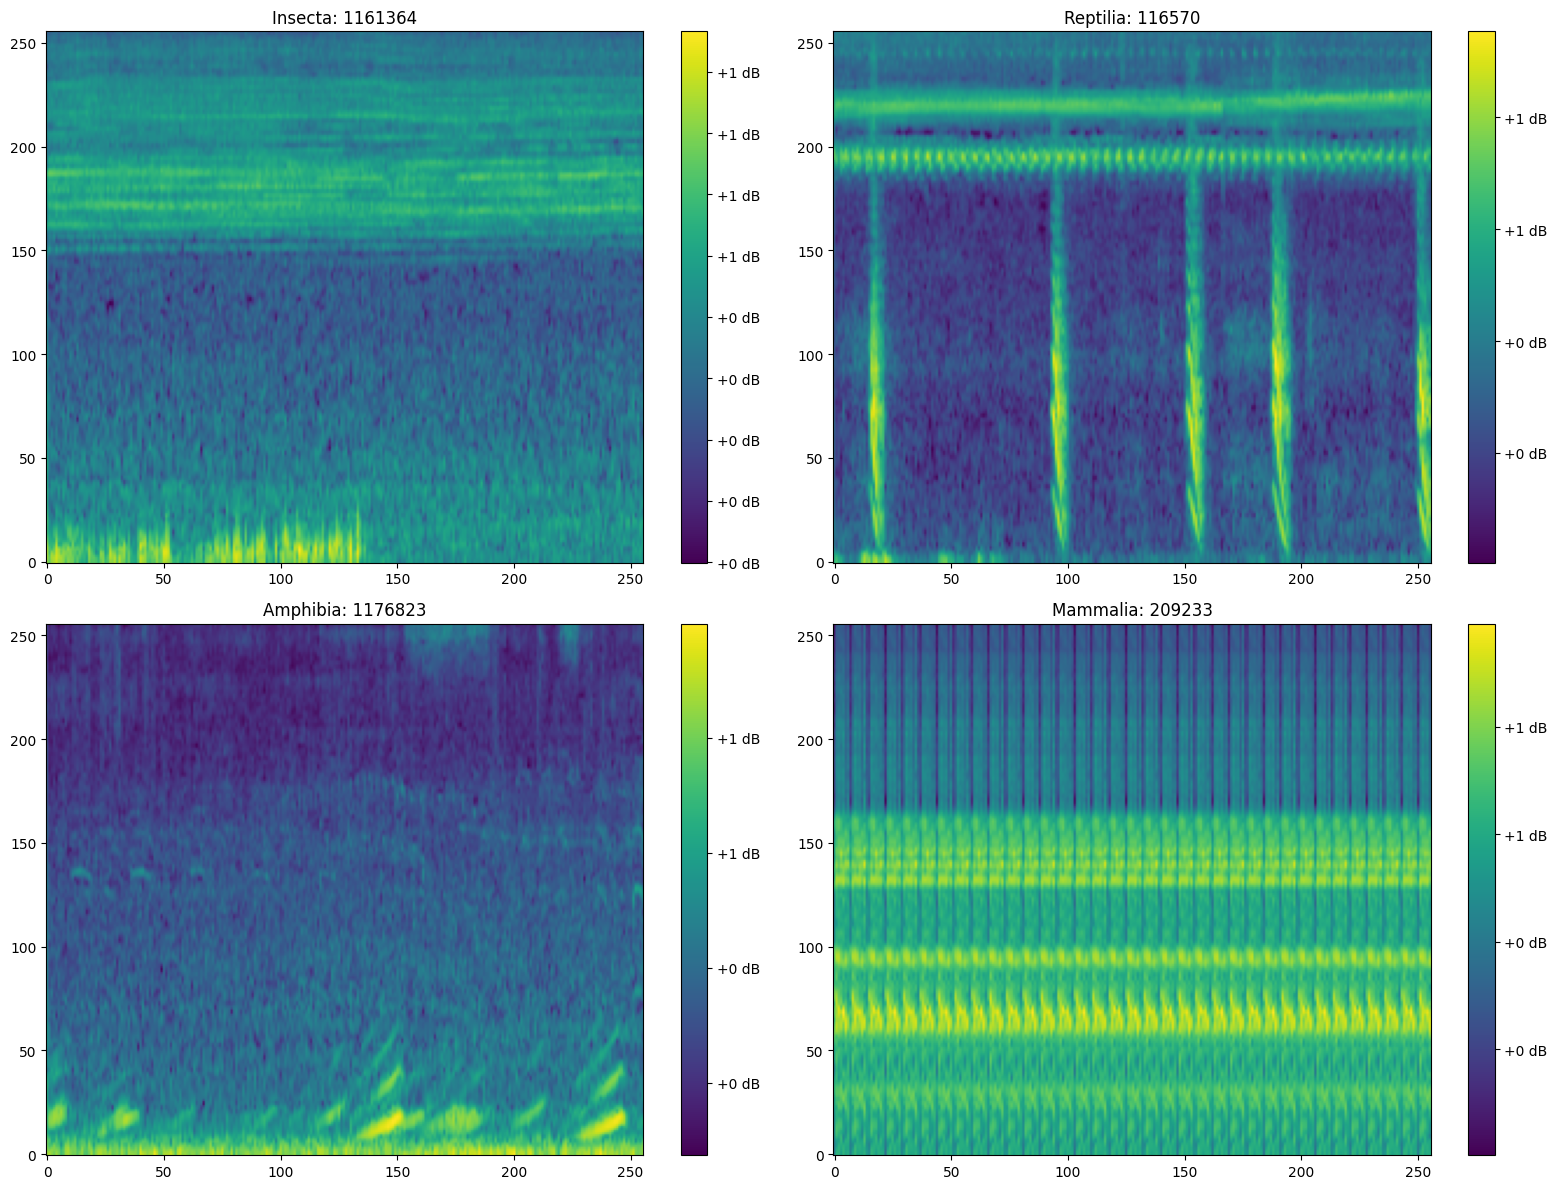

In [6]:

samples = []
displayed_classes = set()

max_samples = min(4, len(all_bird_data))

for i, row in working_df.iterrows():
    if i >= (config.N_MAX or len(working_df)):
        break
        
    if row['samplename'] in all_bird_data:
        if config.DEBUG_MODE:
            if row['class'] not in displayed_classes:
                samples.append((row['samplename'], row['class'], row['primary_label']))
                displayed_classes.add(row['class'])
        else:
            if row['class'] not in displayed_classes:
                samples.append((row['samplename'], row['class'], row['primary_label']))
                displayed_classes.add(row['class'])
        
        if len(samples) >= max_samples:  
            break

if samples:
    plt.figure(figsize=(16, 12))
    
    for i, (samplename, class_name, species) in enumerate(samples):
        plt.subplot(2, 2, i+1)
        plt.imshow(all_bird_data[samplename], aspect='auto', origin='lower', cmap='viridis')
        plt.title(f"{class_name}: {species}")
        plt.colorbar(format='%+2.0f dB')
    
    plt.tight_layout()
    debug_note = "debug_" if config.DEBUG_MODE else ""
    plt.show()